In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Датасет

Два признака (x₁, x₂) и два класса:
- **Класс 1** (синий) — точки внутри круга радиуса 2
- **Класс 0** (красный) — точки во внешнем кольце (радиус 3–5)

Линейная граница (прямая) не может разделить эти классы — нужна нелинейная модель.

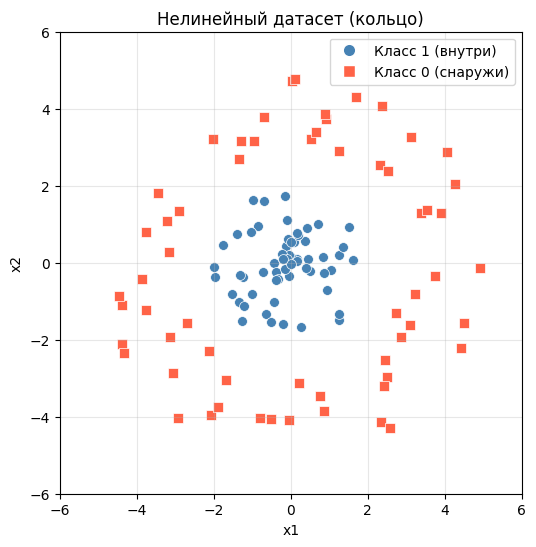

In [3]:
random.seed(42)
n_per_class = 60

data = []

# Класс 1 — внутренний круг (радиус 0..2)
for _ in range(n_per_class):
    r     = random.uniform(0, 2)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 1))

# Класс 0 — внешнее кольцо (радиус 3..5)
for _ in range(n_per_class):
    r     = random.uniform(3, 5)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 0))

features = [(x1, x2) for x1, x2, _ in data]
labels   = [label for _, _, label in data]

# Визуализация датасета
plt.figure(figsize=(6, 6))
for (x1, x2), label in zip(features, labels):
    color  = 'steelblue' if label == 1 else 'tomato'
    marker = 'o'         if label == 1 else 's'
    plt.scatter(x1, x2, color=color, marker=marker, s=50, edgecolors='white', linewidths=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1 (внутри)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0 (снаружи)'),
]
plt.legend(handles=legend_elements)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Нелинейный датасет (кольцо)')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация границы решения

`plot_decision_boundary(predict_fn)` принимает функцию `predict_fn(x1, x2) → 0 или 1` и рисует:
- закрашенные зоны — области, которые модель относит к каждому классу
- фиолетовую линию — саму границу решения
- точки — обучающий датасет

In [4]:
def plot_decision_boundary(predict_fn, title='Граница решения'):
    """
    Визуализирует границу решения нейронной сети.

    predict_fn — функция (x1, x2) -> 0 или 1 (или вероятность).
                 Строит сетку точек, вызывает predict_fn для каждой и
                 закрашивает области в цвета классов.
    """
    h = 0.12  # шаг сетки: меньше — точнее, но медленнее

    x1_vals = np.arange(-6, 6 + h, h)
    x2_vals = np.arange(-6, 6 + h, h)
    xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

    # Вызываем predict_fn для каждой точки сетки
    Z = np.array([[predict_fn(x1, x2) for x1 in x1_vals] for x2 in x2_vals])

    plt.figure(figsize=(6, 6))

    # Закрашиваем зоны классов
    plt.contourf(xx1, xx2, Z, alpha=0.35, levels=1, colors=['tomato', 'steelblue'])
    # Граница решения (там где predict_fn = 0.5)
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2)

    # Точки датасета поверх фона
    for (x1, x2), label in zip(features, labels):
        color  = 'steelblue' if label == 1 else 'tomato'
        marker = 'o'         if label == 1 else 's'
        plt.scatter(x1, x2, color=color, marker=marker, s=50,
                    edgecolors='white', linewidths=0.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0'),
        Line2D([0], [0], color='purple', linewidth=2, label='Граница решения'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Нейронная сеть

Идея нейронной сети заключается в том, чтобы объединить персептроны в нейронную сеть, а с помощью функций активации добавить нелинейности. Таким образом у нас есть база ввиде нейрона/персептрона, который выглядит как `func_activation(x1*w1+xn*wn+b)`. Затем мы задаем архитектуру нейронной сети, то есть формируем слои и в кажом слое кол-во нейроннов и их функции активации. При это результаты предыдущего слоя идут на вход текущему слою, а выходы текущего слоя идут на вход следующему слою. Такие слои называются скрытыми, там находятся оснонвые параметры. Также есть входной слой, который задает "форму" данных и выходной слой, который определяет формат ответа модели. Обучение происходит через обратное распространение или другими словами градиентный спуск, когда мы начинаем вычислять результаты нейронной сети справа на лево. А forward pass это, когда модель в режиме инференса, то есть получения прогнозов. То есть для программной реализации обучения нейронной сети нам нужно сделать базовую функцию формулы нейрона, список весов, функцию формулы активации.

In [6]:
print(features[:5])
print(labels[:5])
print(set(labels))

[(1.263095264869457, 0.20014213501597494), (0.09215033239365172, 0.5422848145486548), (-0.6546499354697413, -1.3194668844492923), (1.5246941048253313, 0.9269549130518164), (0.8290976383212447, 0.15706429841391029)]
[1, 1, 1, 1, 1]
{0, 1}


In [5]:
import math

def linear_formula(x1, x2, w1, w2, b):
  return x1*w1 + x2*w2 + b

def sigmoid(predict_value):
  return 1 / (1 + math.exp(-predict_value))

def relu(predict_value):
  if predict_value <= 0:
    return 0
  return predict_value

# def update_weights_log_loss(y, y_pred, x1, x2, w1, w2):
#   w1 = w1 + learning_rate * (y - y_pred) * x1
#   w2 = w2 + learning_rate * (y - y_pred) * x2
#   b  = b + learning_rate * (y - y_pred)
#   return w1, w2, b

def calc_log_loss(y, y_pred):
    return -y * math.log(y_pred) - (1 - y) * math.log(1 - y_pred)

In [13]:
random.seed(42)
epoches = 1000
learning_rate = 0.01

# First hidden layer
l1_p1_w1 = round(random.uniform(-0.5, 0.5), 2)
l1_p1_w2 = round(random.uniform(-0.5, 0.5), 2)
l1_p1_b = round(random.uniform(-0.5, 0.5), 2)

l1_p2_w1 = round(random.uniform(-0.5, 0.5), 2)
l1_p2_w2 = round(random.uniform(-0.5, 0.5), 2)
l1_p2_b = round(random.uniform(-0.5, 0.5), 2)

l1_p3_w1 = round(random.uniform(-0.5, 0.5), 2)
l1_p3_w2 = round(random.uniform(-0.5, 0.5), 2)
l1_p3_b = round(random.uniform(-0.5, 0.5), 2)

# Second, ouput layer
l2_p1_w1 = round(random.uniform(-0.5, 0.5), 2)
l2_p1_w2 = round(random.uniform(-0.5, 0.5), 2)
l2_p1_w3 = round(random.uniform(-0.5, 0.5), 2)
l2_p1_b = round(random.uniform(-0.5, 0.5), 2)

def get_predict(x1, x2):
  l1_p1_predict = relu(linear_formula(x1, x2, l1_p1_w1, l1_p1_w2, l1_p1_b))
  l1_p2_predict = relu(linear_formula(x1, x2, l1_p2_w1, l1_p2_w2, l1_p2_b))
  output_predict = sigmoid(linear_formula(l1_p1_predict, l1_p2_predict, l2_p1_w1, l2_p1_w2, l2_p1_b))
  return output_predict

for epoch in range(epoches):
  if epoch % 100 == 0:
    total_loss = sum(calc_log_loss(y, get_predict(x1, x2)) for x1, x2, y in data)
    print(f"{epoch=} {total_loss=:.2f}")
    # print(f"{l1_p1_w1=:.2f} {l1_p1_w2=:.2f} {l1_p1_b=:.2f}")

  random_dot_index = random.randint(0, len(labels)-1)
  input_x1, input_x2 = features[random_dot_index]
  y = labels[random_dot_index]

  # Forward pass
  l1_p1_y_value = linear_formula(input_x1, input_x2, l1_p1_w1, l1_p1_w2, l1_p1_b)
  l1_p1_y_predict = relu(l1_p1_y_value)

  l1_p2_y_value = linear_formula(input_x1, input_x2, l1_p2_w1, l1_p2_w2, l1_p2_b)
  l1_p2_y_predict = relu(l1_p2_y_value)

  l1_p3_y_value = linear_formula(input_x1, input_x2, l1_p3_w1, l1_p3_w2, l1_p3_b)
  l1_p3_y_predict = relu(l1_p3_y_value)

  l2_p1_y_value = l1_p1_y_predict * l2_p1_w1 + l1_p2_y_predict * l2_p1_w2 + l1_p3_y_predict * l2_p1_w3 + l1_p3_b
  l2_p1_y_predict = sigmoid(l2_p1_y_value)

  # Backpropagation
  # Сначала обновляем веса выходного слоя
  output_layer_error = (y - l2_p1_y_predict)
  l2_p1_w1 += learning_rate * output_layer_error * l1_p1_y_predict
  l2_p1_w2 += learning_rate * output_layer_error * l1_p2_y_predict
  l2_p1_w3 += learning_rate * output_layer_error * l1_p3_y_predict
  l2_p1_b  += learning_rate * output_layer_error

  # Затем обновляем веса скрытого слоя
  # Чтобы скрытый слой "знал" об ошибке следующего слоя мы передаем ему ошибку выходного слоя, но
  # также домножаем ошибку на вес нейрона в выходном слое, чтобы наиболее важные нейронны получали "больше обратной связи"
  if l1_p1_y_value > 0:
    l1_p1_w1 += learning_rate * output_layer_error * l2_p1_w1 * input_x1
    l1_p1_w2 += learning_rate * output_layer_error * l2_p1_w1 * input_x2
    l1_p1_b  += learning_rate * output_layer_error * l2_p1_w1
  
  # тк веса обновляем через производную от функции ошибки, а функция ошибки relu, то
  # в ее производной мы не обновляем веса, если значение функции нейрона меньше или равно нулю
  if l1_p2_y_value > 0:
    l1_p2_w1 += learning_rate * output_layer_error * l2_p1_w2 * input_x1
    l1_p2_w2 += learning_rate * output_layer_error * l2_p1_w2 * input_x2
    l1_p2_b  += learning_rate * output_layer_error * l2_p1_w2

  if l1_p3_y_value > 0:
    l1_p3_w1 += learning_rate * output_layer_error * l2_p1_w3 * input_x1
    l1_p3_w2 += learning_rate * output_layer_error * l2_p1_w3 * input_x2
    l1_p3_b  += learning_rate * output_layer_error * l2_p1_w3


epoch=0 total_loss=82.90
epoch=100 total_loss=79.89
epoch=200 total_loss=77.27
epoch=300 total_loss=75.16
epoch=400 total_loss=71.85
epoch=500 total_loss=69.48
epoch=600 total_loss=66.70
epoch=700 total_loss=65.10
epoch=800 total_loss=64.28
epoch=900 total_loss=63.70


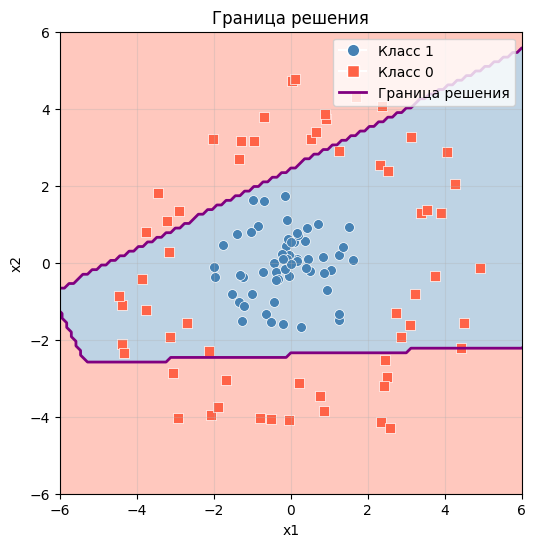

In [10]:
def predict_fn(x1, x2):
  predict = get_predict(x1, x2)
  if predict >= 0.5:
    return 1
  else:
    return 0

plot_decision_boundary(predict_fn)